In [2]:
# visualize the MAMujoco Datasets

import numpy as np
import matplotlib.pyplot as plt

# import gym envs
from gym.spaces import Box, Discrete
from utils.make_env import make_env
from utils.env_wrappers import DummyVecEnv

# env check
try:
    from multiagent_mujoco.mujoco_multi import MujocoMulti
except:
    print ('MujocoMulti not installed')

from bandit import ContinuousBanditEnv

from utils.buffer import ReplayBuffer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

import random
import torch
import os
# make parallel MA-Env
def make_parallel_env(env_id, seed, discrete_action):
    def get_env_fn(rank):
        env = make_env(env_id, discrete_action=discrete_action)
        env.seed(seed + rank * 1000)
        np.random.seed(seed + rank * 1000)
        return env
    return DummyVecEnv([get_env_fn(0)])


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import numpy as np
import random
import os 

def load_and_extract_trajectories(dir, num_agents):
    all_trajectories = []  # 存储所有代理的轨迹

    for i in range(num_agents):
        # 加载每个代理的数据
        curr_obs = np.load(f"{dir}/obs_{i}.npy")
        curr_acs = np.load(f"{dir}/acs_{i}.npy")
        curr_rews = np.load(f"{dir}/rews_{i}.npy")
        curr_next_obs = np.load(f"{dir}/next_obs_{i}.npy")
        curr_dones = np.load(f"{dir}/dones_{i}.npy")
        curr_states = np.load(f"{dir}/states_{i}.npy")
        curr_next_states = np.load(f"{dir}/next_states_{i}.npy")

        # 找到所有结束标志的位置
        done_indices = np.where(curr_dones == 1)[0]

        # 提取轨迹
        trajectories = []
        start_index = 0  # 轨迹的起始索引

        for end_index in done_indices:
            # 切片提取当前轨迹
            current_trajectory = {
                'obs': curr_obs[start_index:end_index + 1].tolist(),
                'ac': curr_acs[start_index:end_index + 1].tolist(),
                'rew': curr_rews[start_index:end_index + 1].tolist(),
                'next_obs': curr_next_obs[start_index:end_index + 1].tolist(),
                'done': curr_dones[start_index:end_index + 1].tolist(),
                'state': curr_states[start_index:end_index + 1].tolist(),
                'next_state': curr_next_states[start_index:end_index + 1].tolist()
            }
            trajectories.append(current_trajectory)  # 保存当前轨迹
            start_index = end_index + 1  # 更新起始索引为下一个时间步

        # 处理最后一条轨迹（如果没有结束标志）
        if start_index < len(curr_dones):
            current_trajectory = {
                'obs': curr_obs[start_index:].tolist(),
                'ac': curr_acs[start_index:].tolist(),
                'rew': curr_rews[start_index:].tolist(),
                'next_obs': curr_next_obs[start_index:].tolist(),
                'done': curr_dones[start_index:].tolist(),
                'state': curr_states[start_index:].tolist(),
                'next_state': curr_states[start_index:].tolist()
            }
            trajectories.append(current_trajectory)

        all_trajectories.append(trajectories)  # 将当前代理的轨迹添加到总轨迹列表中

    return all_trajectories  # 返回所有代理的轨迹

def mix_datasets(quality, meta_dir, seed_nums, num_agents):
    save_dir = os.path.join(meta_dir, f"{quality}/mixed_data")  # 使用 os.path.join 拼接路径
    dirs = []

    for id in range(seed_nums):
        curr_dir = os.path.join(meta_dir, f"{quality}/seed_{id}_data")  # 使用 os.path.join 拼接路径
        dirs.append(curr_dir)


    all_datasets = []  # 存储所有数据集的代理轨迹

    # 加载所有数据集并提取轨迹
    for dir in dirs:
        datasets = load_and_extract_trajectories(dir, num_agents)
        all_datasets.append(datasets)  # 将每个数据集的代理轨迹添加到列表中

    # 随机抽样以均匀混合
    mixed_trajectories = {agent_id: [] for agent_id in range(num_agents)}  # 使用字典存储每个代理的混合轨迹

    for agent_id in range(num_agents):
        for datasets in all_datasets:
            # 获取当前代理的所有轨迹
            agent_trajectories = datasets[agent_id]
            
            # 确保 agent_trajectories 不为空
            if agent_trajectories:
                # 计算采样数量（取 1/5）
                n = max(1, len(agent_trajectories) // 5)  # 确保至少抽取 1 条轨迹
                
                # 随机抽样
                mixed_trajectories[agent_id].extend(random.sample(agent_trajectories, min(n, len(agent_trajectories))))

    # 打乱顺序
    for agent_id in mixed_trajectories:
        random.shuffle(mixed_trajectories[agent_id])  # 分别打乱每个代理的轨迹顺序

    # 创建新的数据集
    new_datasets = {agent_id: {
        'obs': [],
        'ac': [],
        'rew': [],
        'next_obs': [],
        'done': [],
        'state': [],
        'next_state': []
    } for agent_id in range(num_agents)}  # 使用字典存储每个代理的新数据集

    # 将混合后的轨迹按键存储到新的数据集中
    for agent_id, trajectories in mixed_trajectories.items():
        for trajectory in trajectories:
            new_datasets[agent_id]['obs'].extend(trajectory['obs'])
            new_datasets[agent_id]['ac'].extend(trajectory['ac'])
            new_datasets[agent_id]['rew'].extend(trajectory['rew'])
            new_datasets[agent_id]['next_obs'].extend(trajectory['next_obs'])
            new_datasets[agent_id]['done'].extend(trajectory['done'])
            new_datasets[agent_id]['state'].extend(trajectory['state'])
            new_datasets[agent_id]['next_state'].extend(trajectory['next_state'])

    # 检查并创建保存目录
    os.makedirs(save_dir, exist_ok=True)  # 创建目录，如果已存在则不报错

    # 将新的数据集存储为 .npy 文件
    for agent_id in range(num_agents):
        np.save(f"{save_dir}/obs_{agent_id}.npy", new_datasets[agent_id]['obs'])
        np.save(f"{save_dir}/acs_{agent_id}.npy", new_datasets[agent_id]['ac'])
        np.save(f"{save_dir}/rews_{agent_id}.npy", new_datasets[agent_id]['rew'])
        np.save(f"{save_dir}/next_obs_{agent_id}.npy", new_datasets[agent_id]['next_obs'])
        np.save(f"{save_dir}/dones_{agent_id}.npy", new_datasets[agent_id]['done'])
        np.save(f"{save_dir}/states_{agent_id}.npy", new_datasets[agent_id]['state'])
        np.save(f"{save_dir}/next_states_{agent_id}.npy", new_datasets[agent_id]['next_state'])

In [54]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def vis_data(env_id, data_type, seed, legend_label=False, save_fig=False):

    discrete_action = False
    device = f"cuda:{1}"
    rew_scale = 1.0
    # dataset_dir = '/home/qiaodan/Code/diffmarl/datasets' + '/' + env_id + '/' + data_type + '/' + 'seed_{}_data'.format(dataset_id)
    dataset_dir = '/home/qiaodan/Code/diffmarl/datasets/mix_hc/{}/mixed_data'.format(data_type)


    if env_id == 'HalfCheetah-v2':
        nagents = 2
        buffer_length = int(1e6)  # dataset transitions numbers
        episode_length = int(1000)
    elif env_id in ['simple_spread', 'simple_tag', 'simple_world']:
        nagents = 3
        buffer_length = int(1e6)
        episode_length = int(25)

    batch_size = 1000
    use_gpu = True

    ### make env
    if env_id in ['simple_spread', 'simple_tag', 'simple_world']:
        env = make_parallel_env(env_id, seed, discrete_action)
        env_args, env_info = None, None
    elif env_id == "bandit":
        env = ContinuousBanditEnv()
        env_args, env_info = None, None
    else:
        env_args = {"scenario": env_id, "episode_limit": 1000, "agent_conf": '2x3', "agent_obsk": 0,}
        env = MujocoMulti(env_args=env_args)
        env.seed(seed)
        env_info = env.get_env_info()

    # load full offline datasets to buffer
    if env_id in ['simple_spread', 'simple_tag', 'simple_world', 'bandit']:
        replay_buffer = ReplayBuffer(
            buffer_length, nagents,
            [obsp.shape[0] for obsp in env.observation_space],
            [acsp.shape[0] if isinstance(acsp, Box) else acsp.n for acsp in env.action_space], device = device
        )
    else:
        replay_buffer = ReplayBuffer(
            buffer_length, nagents,
            [env_info['obs_shape'] for _ in env.observation_space],
            [acsp.shape[0] for acsp in env.action_space],
            is_mamujoco=True,
            state_dims=[env_info['state_shape'] for _ in env.observation_space], device = device
        )
    replay_buffer.load_batch_data(dataset_dir, rew_scale = rew_scale)

    if np.isinf(replay_buffer.ave_reward):   # 如果变量是 inf, 代表这条轨迹没有 done=True，要进行 scale
        replay_buffer.ave_reward = replay_buffer.sum_reward / (replay_buffer.filled_i/episode_length)
    print('Average_reward:', replay_buffer.ave_reward)

    # sample = replay_buffer.sample(batch_size, to_gpu=use_gpu)


    # replay_buffer.obs_buffs[0].shape, replay_buffer.obs_buffs[0]
    states = replay_buffer.state_buffs[0]
    actions = np.concatenate((replay_buffer.ac_buffs[0], replay_buffer.ac_buffs[1]), axis=1)


    # 将状态降维到2维
    state_pca = PCA(n_components=2)
    states_2d = state_pca.fit_transform(states)

    # 将动作降维到2维
    action_pca = PCA(n_components=2)
    actions_2d = action_pca.fit_transform(actions)

    # 归一化到0-1范围
    scaler = MinMaxScaler()
    actions_2d_normalized = scaler.fit_transform(actions_2d)

    # 分别生成动作的颜色
    action_colors_x = plt.cm.Blues(actions_2d_normalized[:, 0])
    action_colors_y = plt.cm.PuRd(actions_2d_normalized[:, 1])

    # 混合动作颜色
    mixed_colors = (action_colors_x[:, :3] + action_colors_y[:, :3]) / 2


    # 绘制散点图
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    scatter = ax.scatter(states_2d[:, 0], states_2d[:, 1], c=mixed_colors, s=10)
    ax.set_xlim([-50, 50])
    ax.set_ylim([-50, 50])
    ax.set_xlabel('State Dimension 1', fontsize=12)
    ax.set_ylabel('State Dimension 2', fontsize=12)
    ax.set_title('Mixed Dataset - {}'.format(data_type).title(), fontsize=15)
    

    if legend_label:
        # 在主图中插入颜色渐变 bar，放在边框外侧右方
        axins = inset_axes(ax, width="5%", height="85%", loc='right', borderpad=-6)

        # 调整位置，使其位于边框外侧
        axins.set_position([0.9, 0.2, 0.03, 0.8])  # [左, 下, 宽, 高]

        gradient = np.linspace(0, 1, 256)
        gradient = np.vstack((gradient, gradient))

        # 创建自定义 colormap
        cmap = np.empty((256, 256, 3))
        for i in range(256):
            for j in range(256):
                blue = np.array(plt.cm.Blues(gradient[0, i])[:3])
                red = np.array(plt.cm.PuRd(gradient[0, j])[:3])
                cmap[i, j, :] = (blue + red) / 2

        axins.imshow(cmap, aspect='auto', extent=[0, 1, 0, 1])
        axins.set_title('Joint Actions', fontsize=12)
        axins.set_xlabel('Act. Dim. 1', fontsize=12)
        axins.set_ylabel('Act. Dim. 2', fontsize=12)
        axins.xaxis.set_label_position('top')
        axins.xaxis.set_ticks_position('top')
        axins.yaxis.set_ticks_position('left')
        axins.tick_params(axis='both', which='major', labelsize=6)

    save_dir = '/home/qiaodan/Code/diffmarl/results/plot/Abla3'
    if save_fig:
        os.makedirs(save_dir, exist_ok=True)  # 创建目录，如果已存在则不报错
        # 保存图形，指定文件名
        plt.savefig(os.path.join(save_dir, '{}_mix.png'.format(data_type)), dpi=200, bbox_inches='tight')  # 可以根据需要更改文件名和格式
    else:
        plt.show()

    plt.close(fig)  # 关闭图形以释放内存


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/mix_hc/expert/mixed_data...
Average_reward: 3573.3593780641777


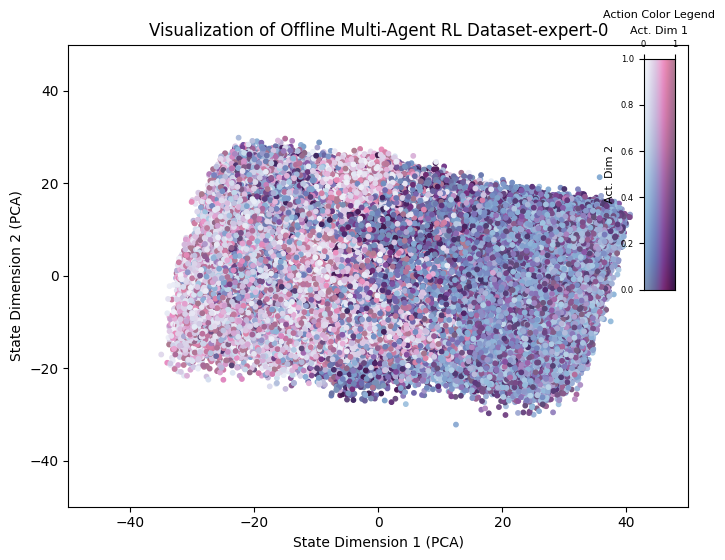

In [11]:
# dataset params
data_type = ['expert', 'medium', 'medium-replay', 'random'] 
# 假设你有五个不同seeds的目录
meta_dir = "/home/qiaodan/Code/diffmarl/datasets/mix_hc/"
seed_nums = 5
num_agents = 2  # 根据实际情况设置代理数量

for dataset_type in data_type:
    mix_datasets(dataset_type, meta_dir, seed_nums, num_agents)
    print('Mixed Datasets {} Done'.format(dataset_type))

# 合成4个质量的datasets


In [56]:
env_id = 'HalfCheetah-v2'  # MPE
types = ['expert', 'medium', 'medium-replay'] 
for type in types:
    vis_data(env_id, data_type=type, seed=44, save_fig=True)

/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/mix_hc/expert/mixed_data...
Average_reward: 3573.3593780641777


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/mix_hc/medium/mixed_data...
Average_reward: 1814.0031979688379


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/mix_hc/medium-replay/mixed_data...
Average_reward: 479.67622877766155


In [57]:
vis_data(env_id, data_type='random', seed=44, legend_label=True, save_fig=True)

/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/mix_hc/random/mixed_data...
Average_reward: -283.60758455319785


: 